# TakeMeter — Fine-Tuning Experiment
### CodePath AI201 · Project 3

This notebook is based on the CodePath AI201 Project 3 starter framework. CodePath provided the fine-tuning and evaluation infrastructure; my work included dataset creation and annotation, label taxonomy design, zero-shot prompt development, experiment execution, and error analysis.

## Experiment
This notebook fine-tunes a DistilBERT text classifier on a manually labeled dataset of 212 community-forum posts and compares its performance with a zero-shot Llama 3.3 70B baseline.

## Setup

This experiment was run in Google Colab using a T4 GPU runtime.

In [ ]:
# Install any dependencies not pre-installed on Colab
!pip install -q groq python-dotenv
print("✅ Dependencies ready")

In [ ]:
import pandas as pd
import numpy as np
import json
import time

from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score, classification_report,
    confusion_matrix, ConfusionMatrixDisplay,
)
import matplotlib.pyplot as plt

import torch
from transformers import (
    AutoTokenizer,
    AutoModelForSequenceClassification,
    TrainingArguments,
    Trainer,
    DataCollatorWithPadding,
)
from datasets import Dataset
import warnings
warnings.filterwarnings("ignore")

print("✅ Imports complete")
print(f"PyTorch version: {torch.__version__}")
print(f"GPU available: {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"GPU: {torch.cuda.get_device_name(0)}")

✅ Imports complete
PyTorch version: 2.11.0+cu128
GPU available: True
GPU: Tesla T4


---
## Section 1: Load Your Dataset

Upload your labeled CSV and define your label map.  
Your CSV must have at least two columns: `text` (the post/comment) and `label` (your string label).

In [ ]:
LABEL_MAP = {
    "technical_help":    0,
    "showcase_reaction": 1,
    "critique_feedback": 2,
    "meta_opinion":      3,
}

ID_TO_LABEL = {v: k for k, v in LABEL_MAP.items()}
NUM_LABELS = len(LABEL_MAP)
print(f"Labels: {LABEL_MAP}")
print(f"Number of labels: {NUM_LABELS}")

Labels: {'technical_help': 0, 'showcase_reaction': 1, 'critique_feedback': 2, 'meta_opinion': 3}
Number of labels: 4


In [ ]:
# Upload your CSV from your computer
from google.colab import files
print("Select your labeled dataset CSV file...")
uploaded = files.upload()
CSV_PATH = list(uploaded.keys())[0]
print(f"Uploaded: {CSV_PATH}")

Select your labeled dataset CSV file...


Saving takemeter_dataset_combined.csv to takemeter_dataset_combined.csv
Uploaded: takemeter_dataset_combined.csv


In [ ]:
# Load and validate your dataset
df = pd.read_csv(CSV_PATH)

print(f"Columns: {df.columns.tolist()}")
print(f"Total examples: {len(df)}")
print()
print("Label distribution:")
print(df["label"].value_counts())

# Validate all labels are in LABEL_MAP
unknown = set(df["label"].unique()) - set(LABEL_MAP.keys())
if unknown:
    print(f"\n⚠️  Labels in CSV not found in LABEL_MAP: {unknown}")
    print("Update your LABEL_MAP above to include all labels.")
else:
    print("\n✅ All labels match your LABEL_MAP")

# Convert string labels to integers
df["label_id"] = df["label"].map(LABEL_MAP)
df = df.dropna(subset=["label_id"])
df["label_id"] = df["label_id"].astype(int)

Columns: ['id', 'text', 'label', 'source_site', 'source_url', 'source_context', 'notes']
Total examples: 212

Label distribution:
label
technical_help       87
showcase_reaction    42
meta_opinion         42
critique_feedback    41
Name: count, dtype: int64

✅ All labels match your LABEL_MAP


---
## Section 2: Prepare Data for Training

Splits your dataset into train / validation / test sets and tokenizes the text.

In [ ]:
# Train / val / test split — 70% / 15% / 15%
# Stratified so each split has roughly the same label distribution.
train_df, temp_df = train_test_split(
    df, test_size=0.30, random_state=42, stratify=df["label_id"]
)
val_df, test_df = train_test_split(
    temp_df, test_size=0.50, random_state=42, stratify=temp_df["label_id"]
)

print(f"Train: {len(train_df)} examples")
print(f"Validation: {len(val_df)} examples")
print(f"Test: {len(test_df)} examples")
print()
print("Train label distribution:")
print(train_df["label"].value_counts())
print()
print("Test label distribution:")
print(test_df["label"].value_counts())

# Reset indices (needed for clean HuggingFace Dataset conversion)
train_df = train_df.reset_index(drop=True)
val_df   = val_df.reset_index(drop=True)
test_df  = test_df.reset_index(drop=True)

Train: 148 examples
Validation: 32 examples
Test: 32 examples

Train label distribution:
label
technical_help       61
critique_feedback    29
meta_opinion         29
showcase_reaction    29
Name: count, dtype: int64

Test label distribution:
label
technical_help       13
showcase_reaction     7
critique_feedback     6
meta_opinion          6
Name: count, dtype: int64


In [ ]:
# Load tokenizer and tokenize all splits
MODEL_NAME = "distilbert-base-uncased"
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)

def tokenize(examples):
    return tokenizer(examples["text"], truncation=True, max_length=256)

def make_dataset(df_split):
    ds = Dataset.from_pandas(
        df_split[["text", "label_id"]].rename(columns={"label_id": "labels"})
    )
    return ds.map(tokenize, batched=True)

train_dataset = make_dataset(train_df)
val_dataset   = make_dataset(val_df)
test_dataset  = make_dataset(test_df)

data_collator = DataCollatorWithPadding(tokenizer=tokenizer)
print("✅ Tokenization complete")
print(f"Sample keys: {list(train_dataset[0].keys())}")

config.json:   0%|          | 0.00/483 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

Map:   0%|          | 0/148 [00:00<?, ? examples/s]

Map:   0%|          | 0/32 [00:00<?, ? examples/s]

Map:   0%|          | 0/32 [00:00<?, ? examples/s]

✅ Tokenization complete
Sample keys: ['text', 'labels', 'input_ids', 'token_type_ids', 'attention_mask']


---
## Section 3: Fine-Tune Your Model

Loads `distilbert-base-uncased` with a classification head and fine-tunes it on your training data.  
Training runs for 3 epochs and takes **5–15 minutes** on a T4 GPU.

> **Hyperparameter note:** The defaults below work well for datasets of 100–500 examples.  
> If you change any values, note what you changed and why in your README.

In [ ]:
# Load DistilBERT with a classification head
model = AutoModelForSequenceClassification.from_pretrained(
    MODEL_NAME,
    num_labels=NUM_LABELS,
    id2label=ID_TO_LABEL,
    label2id=LABEL_MAP,
)
print(f"✅ Model loaded: {MODEL_NAME}")
print(f"Output labels: {NUM_LABELS}")

model.safetensors:   0%|          | 0.00/268M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

[transformers] DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_transform.weight  | UNEXPECTED | 
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
vocab_projector.bias    | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
classifier.weight       | MISSING    | 
pre_classifier.weight   | MISSING    | 
pre_classifier.bias     | MISSING    | 
classifier.bias         | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


✅ Model loaded: distilbert-base-uncased
Output labels: 4


In [ ]:
def compute_metrics(eval_pred):
    logits, labels = eval_pred
    predictions = np.argmax(logits, axis=-1)
    return {"accuracy": accuracy_score(labels, predictions)}

In [ ]:
# ── Hyperparameters ───────────────────────────────────────────────────────
# num_train_epochs  — passes through the training data; 3 is a good default
#                     for small datasets. Increase cautiously; more epochs
#                     risk overfitting on 200 examples.
# learning_rate     — 2e-5 is the standard starting point for fine-tuning
#                     BERT-family models. Lower → slower but more stable.
# per_device_train_batch_size — 16 fits T4 GPU comfortably.
#                     Reduce to 8 if you get out-of-memory errors.
# ─────────────────────────────────────────────────────────────────────────
training_args = TrainingArguments(
    output_dir="./takemeter-model",
    num_train_epochs=3,
    per_device_train_batch_size=16,
    per_device_eval_batch_size=32,
    learning_rate=2e-5,
    weight_decay=0.01,
    warmup_steps=50,
    eval_strategy="epoch",
    save_strategy="epoch",
    save_total_limit=1,
    load_best_model_at_end=True,
    metric_for_best_model="accuracy",
    logging_steps=10,
    report_to="none",
)

trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=train_dataset,
    eval_dataset=val_dataset,
    data_collator=data_collator,
    compute_metrics=compute_metrics,
)

print("Starting fine-tuning... (5–15 minutes on T4 GPU)")
trainer.train()
print("\n✅ Fine-tuning complete")

Starting fine-tuning... (5–15 minutes on T4 GPU)


Epoch,Training Loss,Validation Loss,Accuracy
1,1.418497,1.417196,0.187500
2,1.402684,1.393355,0.187500
3,1.362975,1.344952,0.468750


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]


✅ Fine-tuning complete


---
## Section 4: Evaluate Fine-Tuned Model on Test Set

Runs inference on your locked test set and generates metrics and a confusion matrix.  
These numbers go directly into your evaluation report.

In [ ]:
# Run inference on the test set
print("Running inference on test set...")
ft_output = trainer.predict(test_dataset)
ft_pred_ids = np.argmax(ft_output.predictions, axis=-1)
ft_true_ids = ft_output.label_ids

ft_probs = torch.nn.functional.softmax(
    torch.tensor(ft_output.predictions), dim=-1
).numpy()

# Overall accuracy
ft_accuracy = accuracy_score(ft_true_ids, ft_pred_ids)
print(f"\n🎯 Fine-tuned model accuracy: {ft_accuracy:.3f}")

# Per-class metrics
label_names = [ID_TO_LABEL[i] for i in range(NUM_LABELS)]
print("\nPer-class metrics (fine-tuned model):")
print(classification_report(ft_true_ids, ft_pred_ids, target_names=label_names, zero_division=0))

Running inference on test set...



🎯 Fine-tuned model accuracy: 0.500

Per-class metrics (fine-tuned model):
                   precision    recall  f1-score   support

   technical_help       0.45      1.00      0.62        13
showcase_reaction       1.00      0.43      0.60         7
critique_feedback       0.00      0.00      0.00         6
     meta_opinion       0.00      0.00      0.00         6

         accuracy                           0.50        32
        macro avg       0.36      0.36      0.30        32
     weighted avg       0.40      0.50      0.38        32



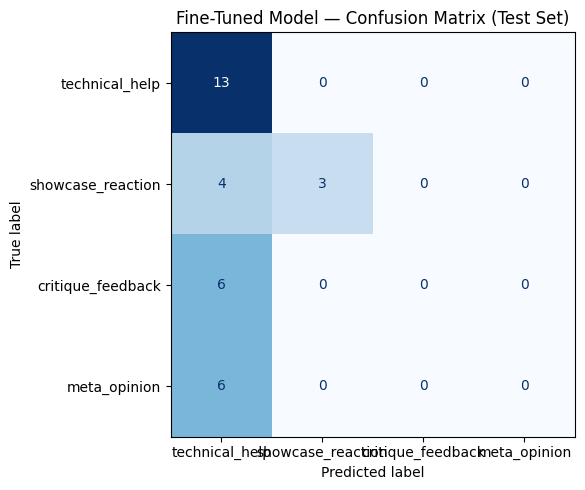

✅ Saved: confusion_matrix.png  →  commit this to your repo and include in README


In [ ]:
# Confusion matrix
cm = confusion_matrix(ft_true_ids, ft_pred_ids)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=label_names)
fig, ax = plt.subplots(figsize=(7, 5))
disp.plot(ax=ax, cmap="Blues", colorbar=False)
ax.set_title("Fine-Tuned Model — Confusion Matrix (Test Set)")
plt.tight_layout()
plt.savefig("confusion_matrix.png", dpi=150)
plt.show()
print("✅ Saved: confusion_matrix.png  →  commit this to your repo and include in README")

In [ ]:
# Print wrong predictions for your error analysis
# Review these carefully — pick 3 to analyze in depth in your README.

wrong_idx = np.where(ft_pred_ids != ft_true_ids)[0]
print(f"Wrong predictions: {len(wrong_idx)} / {len(ft_true_ids)}\n")

for i, idx in enumerate(wrong_idx[:15]):
    text = test_df.iloc[idx]["text"]
    true_label = ID_TO_LABEL[ft_true_ids[idx]]
    pred_label = ID_TO_LABEL[ft_pred_ids[idx]]
    confidence = ft_probs[idx][ft_pred_ids[idx]]
    print(f"--- #{i+1} ---")
    print(f"Text:      {text[:200]}{'...' if len(text) > 200 else ''}")
    print(f"True:      {true_label}")
    print(f"Predicted: {pred_label}  (confidence: {confidence:.2f})")
    print()

Wrong predictions: 16 / 32

--- #1 ---
Text:      Should I add a disclaimer that I don't endorse the technique displayed in the video?
True:      meta_opinion
Predicted: technical_help  (confidence: 0.28)

--- #2 ---
Text:      I think you did a fairly good job of having the sun's warmth in the colors on the trees, but a bit less well on the colors of the rocks.
True:      critique_feedback
Predicted: technical_help  (confidence: 0.28)

--- #3 ---
Text:      Dog Prince Charles watercolor WIP
True:      showcase_reaction
Predicted: technical_help  (confidence: 0.27)

--- #4 ---
Text:      I think you didn't quite manage the big shapes in the rock column. It's rather flat and doesn't really have the bulging on the lower large area.
True:      critique_feedback
Predicted: technical_help  (confidence: 0.28)

--- #5 ---
Text:      Good results Doug! OK I darkened some of the colours. Might be better in gouache. I'm sure you could do better.
True:      critique_feedback
Predicted: technical_

---
## Section 5: Baseline Classifier (Groq)

Runs your zero-shot baseline using `llama-3.3-70b-versatile`.  
You need to write the classification prompt using your label definitions.

In [ ]:
from groq import Groq

from google.colab import userdata
GROQ_API_KEY = userdata.get("GROQ_API_KEY")

assert GROQ_API_KEY, (
    "GROQ_API_KEY not set — add it in the Colab Secrets panel (\U0001f511, left "
    "sidebar) and enable notebook access for this notebook, or use Option B above."
)

client = Groq(api_key=GROQ_API_KEY)
print("✅ Groq client initialized")

✅ Groq client initialized


In [ ]:
SYSTEM_PROMPT = """\
You are a text classifier for posts from online hobbyist art and craft communities
(WetCanvas watercolor forums and KnittingHelp crochet/knitting forums).

Assign each post to EXACTLY ONE of the following four labels.

technical_help
A post that asks about or explains a specific skill, method, material, or process.
The content is instructional or troubleshooting-focused: the poster either has a
problem to solve or is providing a solution to one. The substance is the HOW.
Example: "It sounds like you are still increasing and that is why it is a pancake
shape. Usually it takes a couple inches after you stop the increases for it to
begin to curve."

showcase_reaction
An immediate emotional or aesthetic response to someone's work or post. Primarily
expressive, with little to no instructional or evaluative content. The post shares
a feeling or brief acknowledgment, not a reasoned judgment.
Example: "Wow! What a fabulous gift. It brought a huge smile to my face."

critique_feedback
A post that evaluates work with specific observations about what is or isn't
working, and why. The poster names something concrete (a composition choice,
a color relationship, a structural issue) and makes a judgment about it.
Example: "There isn't really any pattern to the shadow work. The shadows seem
randomly placed rather than being cast by something. I'd recommend designing
a shadow pattern."

meta_opinion
A post expressing a personal view, preference, or general observation about
the craft, community, or materials — not tied to a specific work or technical
problem. Opinionated and discursive; about the landscape of the practice.
Example: "Some teachers can only produce clones; others encourage everyone to
do their own thing. Some are proactive, some reactive and some downright lazy."

IMPORTANT RULES:
- If a post mixes warm reaction language with at least one specific observation
  about WHY something works, label it critique_feedback, not showcase_reaction.
- If a post responds to a problem the poster already flagged (troubleshooting),
  label it technical_help even if it evaluates the work.
- If a post contains actionable advice that could appear in a tutorial or FAQ,
  label it technical_help rather than meta_opinion.

Respond with ONLY the label name — no punctuation, no explanation, nothing else.
Your entire response must be one of these four words exactly:
technical_help
showcase_reaction
critique_feedback
meta_opinion
"""

print("Prompt length:", len(SYSTEM_PROMPT), "characters")

Prompt length: 2446 characters


In [ ]:
def classify_with_groq(text):
    """Classify a single post. Returns a label string or None if unparseable."""
    try:
        response = client.chat.completions.create(
            model="llama-3.3-70b-versatile",
            messages=[
                {"role": "system", "content": SYSTEM_PROMPT},
                {"role": "user", "content": f"Classify this post:\n\n{text}"},
            ],
            temperature=0,
            max_tokens=20,
        )
        raw = response.choices[0].message.content.strip().lower()
        # Match the model's output to a label. Check longest labels first so a
        # label that is a substring of another (e.g. "recommendation" vs.
        # "strong_recommendation") can't be matched by mistake.
        for label in sorted(LABEL_MAP, key=len, reverse=True):
            if raw == label or label in raw:
                return label
        return None  # model output didn't match any known label
    except Exception as e:
        print(f"API error: {e}")
        return None


# Run baseline on test set
print(f"Running baseline on {len(test_df)} examples...")
print("(May take a few minutes — 0.1s delay between requests to respect free-tier limits)\n")

baseline_preds = []
for i, (_, row) in enumerate(test_df.iterrows()):
    pred = classify_with_groq(row["text"])
    baseline_preds.append(pred)
    if (i + 1) % 10 == 0:
        print(f"  {i+1}/{len(test_df)} complete...")
    time.sleep(0.1)

none_count = baseline_preds.count(None)
if none_count > 0:
    print(f"\n⚠️  {none_count} responses could not be parsed.")
    print("Review your prompt — the model may not be outputting clean label names.")

Running baseline on 32 examples...
(May take a few minutes — 0.1s delay between requests to respect free-tier limits)

  10/32 complete...
  20/32 complete...
  30/32 complete...


In [ ]:
# Baseline metrics (exclude unparseable responses)
valid = [(p, t) for p, t in zip(baseline_preds, test_df["label_id"])
         if p is not None]
bl_pred_ids = [LABEL_MAP[p] for p, _ in valid]
bl_true_ids = [t for _, t in valid]

bl_accuracy = accuracy_score(bl_true_ids, bl_pred_ids)
print(f"🎯 Baseline accuracy: {bl_accuracy:.3f}  "
      f"(evaluated on {len(valid)}/{len(test_df)} parseable responses)")
print()
label_names = [ID_TO_LABEL[i] for i in range(NUM_LABELS)]
print("Per-class metrics (baseline):")
print(classification_report(bl_true_ids, bl_pred_ids, target_names=label_names, zero_division=0))

🎯 Baseline accuracy: 0.906  (evaluated on 32/32 parseable responses)

Per-class metrics (baseline):
                   precision    recall  f1-score   support

   technical_help       0.93      1.00      0.96        13
showcase_reaction       0.86      0.86      0.86         7
critique_feedback       1.00      0.67      0.80         6
     meta_opinion       0.86      1.00      0.92         6

         accuracy                           0.91        32
        macro avg       0.91      0.88      0.89        32
     weighted avg       0.91      0.91      0.90        32



---
## Section 6: Compare Results and Export

Side-by-side comparison of both models.  
Download the output files and commit them to your GitHub repo.

In [ ]:
print("=" * 50)
print("RESULTS COMPARISON")
print("=" * 50)
print(f"{'Model':<35} {'Accuracy':>8}")
print("-" * 45)
print(f"{'Zero-shot baseline (Groq)':<35} {bl_accuracy:>8.3f}")
print(f"{'Fine-tuned DistilBERT':<35} {ft_accuracy:>8.3f}")
print("-" * 45)
delta = ft_accuracy - bl_accuracy
direction = "improvement" if delta >= 0 else "regression"
print(f"\nFine-tuning {direction}: {abs(delta):.3f}")
print()
print("Use these numbers in your README evaluation report.")

RESULTS COMPARISON
Model                               Accuracy
---------------------------------------------
Zero-shot baseline (Groq)              0.906
Fine-tuned DistilBERT                  0.500
---------------------------------------------

Fine-tuning regression: 0.406

Use these numbers in your README evaluation report.


In [ ]:
# Save results JSON — commit to your GitHub repo and reference in README
results = {
    "baseline_accuracy": round(bl_accuracy, 4),
    "finetuned_accuracy": round(ft_accuracy, 4),
    "improvement": round(ft_accuracy - bl_accuracy, 4),
    "test_set_size": len(test_df),
    "label_map": LABEL_MAP,
    "model": MODEL_NAME,
}
with open("evaluation_results.json", "w") as f:
    json.dump(results, f, indent=2)

print("✅ Files ready to download:")
print("   evaluation_results.json  — metrics for your README")
print("   confusion_matrix.png     — include in your README")
print()
print("Download via: Files panel (📁) on the left → right-click → Download")

✅ Files ready to download:
   evaluation_results.json  — metrics for your README
   confusion_matrix.png     — include in your README

Download via: Files panel (📁) on the left → right-click → Download


In [ ]:
# Demo classifications
demo_posts = [
    # correct - technical_help
    "It sounds like you are still increasing and that is why it is a pancake shape. Usually it takes a couple inches after you stop the increases for it to begin to curve.",
    # correct - showcase_reaction
    "Wow! What a fabulous gift. It brought a huge smile to my face.",
    # correct - technical_help
    "If you are a loose crocheter you might try going to a smaller hook size. Even tension is something that comes with practice.",
    # wrong - critique_feedback misclassified as technical_help
    "I think you didn't quite manage the big shapes in the rock column. It's rather flat and doesn't really have the bulging on the lower large area.",
    # wrong - meta_opinion misclassified as technical_help
    "Should I add a disclaimer that I don't endorse the technique displayed in the video?",
]

from transformers import pipeline
classifier = pipeline("text-classification", model=trainer.model, tokenizer=tokenizer)

for post in demo_posts:
    result = classifier(post)[0]
    label = result['label']
    confidence = result['score']
    print(f"POST: {post[:80]}...")
    print(f"→ {label}  (confidence: {confidence:.2f})")
    print()

POST: It sounds like you are still increasing and that is why it is a pancake shape. U...
→ technical_help  (confidence: 0.28)

POST: Wow! What a fabulous gift. It brought a huge smile to my face....
→ showcase_reaction  (confidence: 0.29)

POST: If you are a loose crocheter you might try going to a smaller hook size. Even te...
→ technical_help  (confidence: 0.28)

POST: I think you didn't quite manage the big shapes in the rock column. It's rather f...
→ technical_help  (confidence: 0.28)

POST: Should I add a disclaimer that I don't endorse the technique displayed in the vi...
→ technical_help  (confidence: 0.28)

